# RNA to Protein Multimodal Autoencoder — Per-Variety Analysis

**For designs where each variety has its own samples AND its own gene/protein set.**

```
Variety A: 2 treatments x 4 timepoints x 3 reps = 24 samples, gene set A
Variety B: 2 treatments x 4 timepoints x 3 reps = 24 samples, gene set B
```

Because the two varieties do not share a feature space, they are fitted
**independently** and compared afterwards at the level of orthologous genes.

> `leave_variety_out` (train on A, predict B) is **not possible** here and has
> been removed. Its replacement is `leave_treatment_out` within each variety,
> plus the cross-variety result comparison in section 9.

This notebook runs both varieties in one pass. Run cells top to bottom.

## 0 - Setup

In [1]:
# !pip install torch scikit-learn pandas numpy scipy matplotlib seaborn -q

import sys, os, json, warnings
warnings.filterwarnings("ignore")

PROJ = os.getcwd()
if PROJ not in sys.path:
    sys.path.insert(0, PROJ)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path
from IPython.display import display

sns.set_theme(style="ticks", font_scale=1.05)
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"python {sys.version.split()[0]} | torch {torch.__version__} | pandas {pd.__version__}")

python 3.10.12 | torch 2.13.0+cu130 | pandas 2.3.3


## 1 - Configuration

Edit this cell only. Everything downstream reads from it.

Parameters are already scaled for **n = 24 per variety**, which is half what a
pooled analysis would have had. Do not raise `LATENT` above ~8: with 8 design
cells (2 treatments x 4 timepoints) a larger latent space simply memorises them.

In [2]:
# =========================================================================
#                            EDIT THIS BLOCK
# =========================================================================

# --- One entry per variety. Set to None to run the synthetic demo. --------
VARIETIES = {
    "A": dict(rna="data/norin-rnaseq.csv", prot="data/norin-prot.csv",
              meta="data/norin_metadata.csv", mapping="data/norin_protein_gene_mapping.csv"),
    "B": dict(rna="data/cadenza-rnaseq.csv", prot="data/cadenza-prot.csv",
              meta="data/cadenza_metadata.csv", mapping="data/cadenza_protein_gene_mapping.csv"),
}
USE_DEMO = False          # <- set False once your paths above are real

# --- Ortholog map linking variety A protein IDs to variety B protein IDs --
ORTHOLOG_CSV = None      # e.g. "orthologs_A_to_B.csv", columns: id_a, id_b
                         # None -> per-variety results only, no gene-level comparison

# --- Preprocessing (n = 24: keep these small) -----------------------------
N_RNA      = 1500
N_PROT     = 800
RNA_MODE   = "counts"       # "counts" -> CPM+log2 | "logged" -> already normalised
PROT_MODE  = "intensity"    # "intensity" -> log2  | "logged" -> already logged

# --- Autoencoder ----------------------------------------------------------
LATENT       = 6
HIDDEN       = (64, 16)


DROPOUT      = 0.05      # was 0.20
WEIGHT_DECAY = 3e-4      # was 3e-3
PATIENCE     = 100       # was 60

EPOCHS       = 400
LR           = 1e-3


W_RECON = 0.5     # RNA->RNA and protein->protein reconstruction
W_CROSS = 3.0     # RNA->protein  (the term that produces the discordance score)
W_ALIGN = 0.5     # ||z_rna - z_protein||

# --- Cross-validation -----------------------------------------------------
SPLIT_SCHEMES_WANTED = ["leave_condition_out", "leave_treatment_out"]
#   leave_condition_out  8 folds, holds out 3 reps of a treatment x timepoint cell
#   leave_treatment_out  2 folds, train on control -> predict treated
#   leave_timepoint_out  4 folds, temporal extrapolation
#   naive_random         diagnostic only, shows replicate leakage

N_PERM = 2        # label permutations (raise to 5+ for publication)

# =========================================================================
OUT_DIR = Path("results_per_variety")
OUT_DIR.mkdir(exist_ok=True)
(OUT_DIR / "figures").mkdir(exist_ok=True)

MODEL_ORDER = ["mean", "design_only", "cognate_ridge", "pca_ridge", "pls", "multimodal_ae"]
PALETTE     = dict(zip(MODEL_ORDER, sns.color_palette("Set2", 6)))
LABELS      = list(VARIETIES)

print("config loaded")
print(f"  varieties : {LABELS}")
print(f"  latent={LATENT} hidden={HIDDEN} n_rna={N_RNA} n_prot={N_PROT}")
print(f"  splits    : {SPLIT_SCHEMES_WANTED}")

config loaded
  varieties : ['A', 'B']
  latent=6 hidden=(64, 16) n_rna=1500 n_prot=800
  splits    : ['leave_condition_out', 'leave_treatment_out']


## 2 - Load each variety

Nothing is merged or reindexed. Each variety keeps its own gene and protein
universe, and each gets its own preprocessing, its own CV, and its own model.

In [3]:
from rnaprot.multivariety import load_variety, SPLIT_SCHEMES_SINGLE, covariate_matrix_single

DATA, TRUTH = {}, {}

if USE_DEMO:
    from rnaprot.simulate import simulate
    for i, lab in enumerate(LABELS):
        d, t = simulate(n_genes=4000, n_prot=800, n_var=1, seed=i)
        d.meta = d.meta.assign(variety=lab)
        # give each variety its own namespace so nothing accidentally lines up
        d.rna.columns  = [f"{lab}_{g}" for g in d.rna.columns]
        d.prot.columns = [f"{lab}_{p}" for p in d.prot.columns]
        d.cognate = {f"{lab}_{p}": f"{lab}_{g}" for p, g in d.cognate.items()}
        t.index = [f"{lab}_{p}" for p in t.index]
        DATA[lab], TRUTH[lab] = d, t

    # trivial ortholog map for the demo (protN in A <-> protN in B)
    common = [p.split("_", 1)[1] for p in DATA[LABELS[0]].prot.columns][:600]
    pd.DataFrame({"id_a": [f"{LABELS[0]}_{p}" for p in common],
                  "id_b": [f"{LABELS[1]}_{p}" for p in common]}) \
      .to_csv(OUT_DIR / "demo_orthologs.csv", index=False)
    ORTHOLOG_CSV = str(OUT_DIR / "demo_orthologs.csv")
    print("SYNTHETIC demo data. The two varieties are simulated from different")
    print("seeds, so there is no shared biology - the cross-variety comparison")
    print("in section 9 should correctly come back null. That is the calibration.")
else:
    for lab, paths in VARIETIES.items():
        DATA[lab] = load_variety(paths["rna"], paths["prot"], paths["meta"],
                                 paths.get("mapping"), variety_label=lab)
        TRUTH[lab] = None
    print("REAL data loaded.")

print()
for lab, d in DATA.items():
    print(f"--- variety {lab} ---")
    print(d.describe())
    if d.n_samples != 24:
        print(f"  note: expected 24 samples, got {d.n_samples}")
    print()

REAL data loaded.

--- variety A ---
24 samples | 145,065 genes | 5,879 proteins
  varieties : ['V0']
  treatments: ['T0', 'T1']
  timepoints: ['t0', 't1', 't2', 't3']
  replicates: ['r0', 'r1', 'r2']
  cognate pairs mapped: 5,879

--- variety B ---
24 samples | 128,544 genes | 6,105 proteins
  varieties : ['V1']
  treatments: ['T0', 'T1']
  timepoints: ['t0', 't1', 't2', 't3']
  replicates: ['r0', 'r1', 'r2']
  cognate pairs mapped: 6,105



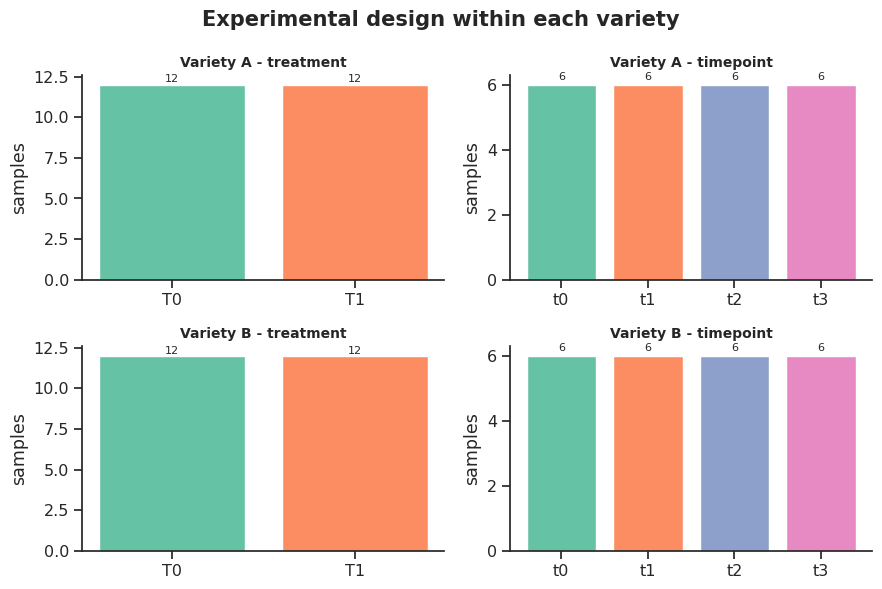

In [4]:
# --- design check, per variety -------------------------------------------
fig, axes = plt.subplots(len(LABELS), 2, figsize=(9, 3.0 * len(LABELS)), squeeze=False)
for r, lab in enumerate(LABELS):
    m = DATA[lab].meta
    for c, col in enumerate(["treatment", "timepoint"]):
        ax = axes[r][c]
        counts = m[col].value_counts().sort_index()
        bars = ax.bar(counts.index, counts.values,
                      color=sns.color_palette("Set2", len(counts)))
        for b in bars:
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.15,
                    str(int(b.get_height())), ha="center", fontsize=8)
        ax.set_title(f"Variety {lab} - {col}", fontweight="bold", fontsize=10)
        ax.set_ylabel("samples")
        ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Experimental design within each variety", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "design.png", dpi=150, bbox_inches="tight")
plt.show()

## 3 - Preprocessing

Fit separately per variety. Library sizes and variance filters are computed
within a variety because the two assemblies have different gene counts and the
CPM denominators are not comparable across them.

Inside cross-validation this is refit on training samples only, so nothing
leaks. The cell below fits on all 24 samples purely so you can eyeball the
filtering before committing.

variety A: 145,065 genes -> 1,500 | 5,879 proteins -> 800 | 7 covariates
variety B: 128,544 genes -> 1,500 | 6,105 proteins -> 800 | 7 covariates


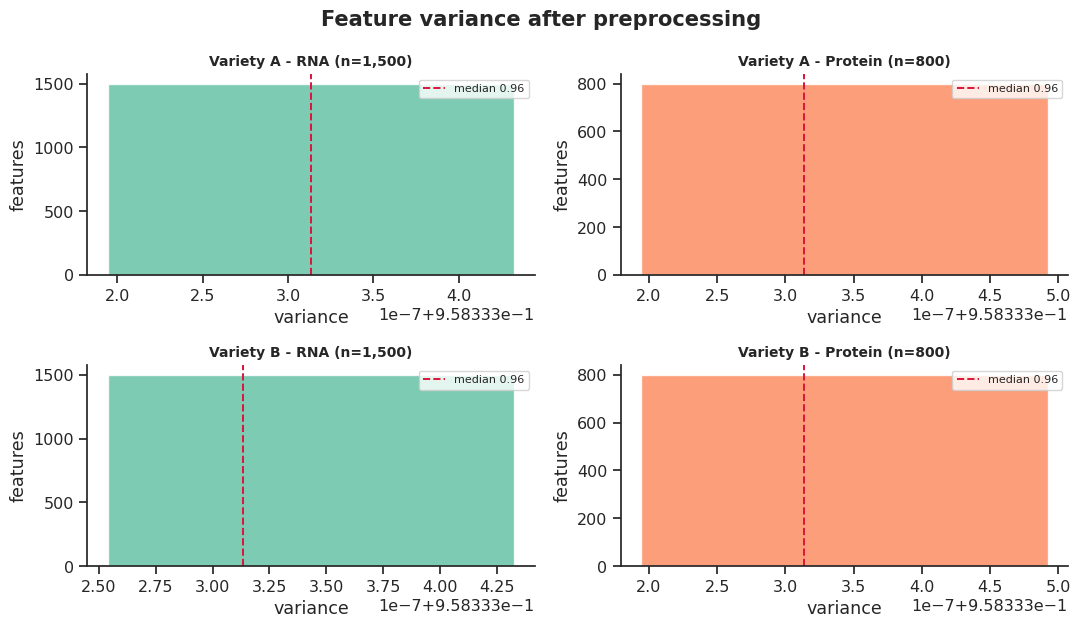

In [5]:
from rnaprot.data import OmicsPreprocessor

# Storage dicts: one entry per variety (e.g. PRE["A"], PRE["B"])
#   PRE  = the fitted preprocessor object itself (keeps the filter/scaling
#          parameters learned from this variety's samples)
#   RMAT = the cleaned, filtered, standardised RNA matrix (samples x genes)
#   PMAT = the cleaned, filtered, standardised protein matrix (samples x proteins)
#   COV  = the design covariate matrix (treatment/timepoint dummy variables)
PRE, RMAT, PMAT, COV = {}, {}, {}, {}

for lab in LABELS:
    d = DATA[lab]   # the OmicsData object loaded earlier for this variety

    # --- fit the preprocessor on THIS variety's samples -----------------
    # OmicsPreprocessor does, in order:
    #   1. normalise RNA (CPM + log2, or pass through if already logged)
    #   2. normalise protein (log2, or pass through if already logged)
    #   3. filter out low-detection genes/proteins
    #   4. impute missing protein values (half-minimum per protein)
    #   5. keep only the N_RNA / N_PROT most variable features
    #   6. standardise everything to zero mean, unit variance
    # np.arange(d.n_samples) tells it "treat every sample as training data" --
    # this full-data fit is ONLY for eyeballing here; inside cross-validation
    # the pipeline refits this on training-fold samples only, so nothing leaks.
    pre = OmicsPreprocessor(n_rna=N_RNA, n_prot=N_PROT,
                            rna_mode=RNA_MODE, prot_mode=PROT_MODE) \
          .fit(d, np.arange(d.n_samples))

    # --- apply the fitted preprocessor to get final numeric matrices ----
    # R : samples x N_RNA   standardised, filtered RNA values
    # P : samples x N_PROT  standardised, filtered protein values
    R, P = pre.transform(d)

    # stash everything for later cells (model fitting, latent factors, etc.)
    PRE[lab], RMAT[lab], PMAT[lab] = pre, R, P

    # --- build the design covariate matrix -------------------------------
    # One-hot / dummy-coded treatment and timepoint columns (variety is
    # constant within this table, since we're inside a single variety, so
    # it's dropped). This is what the "design_only" baseline model uses,
    # and what gets concatenated to the RNA input for every model.
    COV[lab] = covariate_matrix_single(d.meta)

    # --- report what survived filtering -----------------------------------
    # Shows you: original gene/protein counts -> how many were kept after
    # the variance filter, plus how many covariate columns were built.
    # Sanity check: if "kept" numbers look wrong (e.g. 0, or way too few),
    # something is off with N_RNA/N_PROT or the input file format.
    print(f"variety {lab}: {d.rna.shape[1]:,} genes -> {R.shape[1]:,} | "
          f"{d.prot.shape[1]:,} proteins -> {P.shape[1]:,} | "
          f"{COV[lab].shape[1]} covariates")

# =============================================================================
# FIGURE: distribution of feature variance after preprocessing
# =============================================================================
# Purpose: confirm the variance filter did something sensible. You expect a
# right-skewed histogram (many low-variance features, a smaller tail of highly
# variable ones) -- since we KEPT the top-N most variable features, this plot
# shows the variance distribution of the SURVIVORS, not the original full set.
fig, axes = plt.subplots(len(LABELS), 2, figsize=(11, 3.2 * len(LABELS)), squeeze=False)

for r, lab in enumerate(LABELS):
    # one row per variety, one column each for RNA and Protein
    for c, (mat, name) in enumerate([(RMAT[lab], "RNA"), (PMAT[lab], "Protein")]):
        ax = axes[r][c]
        var = mat.var(axis=0)   # per-feature variance across samples

        # Freedman-Diaconis rule picks a sensible bin width automatically;
        # falls back to a fixed 30 bins if the data is too degenerate for
        # that rule to compute (e.g. near-zero variance everywhere).
        try:
            counts, edges = np.histogram(var, bins="fd")
        except Exception:
            lo, hi = float(var.min()), float(var.max()) + 1e-9
            counts, edges = np.histogram(var, bins=30, range=(lo, hi))

        # draw the histogram manually with ax.bar (more robust than ax.hist
        # against the edge cases above)
        ax.bar(edges[:-1], counts, width=np.diff(edges), align="edge",
               color=sns.color_palette("Set2")[c], alpha=0.85)

        # mark the median variance as a reference line
        ax.axvline(float(np.median(var)), color="crimson", lw=1.4, ls="--",
                   label=f"median {np.median(var):.2f}")

        ax.set_title(f"Variety {lab} - {name} (n={mat.shape[1]:,})",
                     fontweight="bold", fontsize=10)
        ax.set_xlabel("variance"); ax.set_ylabel("features")
        ax.legend(fontsize=8)
        ax.spines[["top", "right"]].set_visible(False)   # cleaner plot style

fig.suptitle("Feature variance after preprocessing", fontweight="bold")
plt.tight_layout()

# save to disk (for the paper / records) and also display inline
plt.savefig(OUT_DIR / "figures" / "variance.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 - Cross-validation, per variety

Six models on identical folds within each variety.

| model | uses RNA? | why it is here |
|---|---|---|
| `mean` | no | defines R2 = 0 |
| `design_only` | **no** | if this matches your AE, the model learned the design, not biology |
| `cognate_ridge` | own transcript | the textbook answer |
| `pca_ridge` | yes | best linear latent model |
| `pls` | yes | supervised latent components, DIABLO family |
| `multimodal_ae` | yes | your autoencoder |

`leave_treatment_out` is worth reading carefully. It trains on control and
predicts treated. **A failure there is a biological result**, not a modelling
failure: it means treatment altered the RNA to protein mapping.

In [6]:
from rnaprot import baselines as B
from rnaprot.models import AERegressor
from rnaprot.evaluate import run_cv, oof_r2_table, compare_models


# =============================================================================
# HELPER 1: map each protein to the column index of its cognate transcript
# =============================================================================
def make_cognate_index_fn(cognate):
    """
    Returns a function that, given a fitted preprocessor `pre`, produces an
    array `pairs` where pairs[j] = the column index in the RNA matrix of
    protein j's own transcript (or -1 if unmapped / not in the filtered set).

    Why this has to be a function-returning-a-function: which genes/proteins
    survive the N_RNA/N_PROT variance filter is DIFFERENT in every CV fold
    (the filter is refit on training samples only, see the preprocessing
    cell). So the cognate lookup can't be computed once up front -- it has
    to be recomputed inside every fold, after that fold's own filtering.
    `cog_fn(pre)` gets called fresh each time run_cv() enters a new fold.
    """
    def fn(pre):
        # gpos: gene_id -> column index, for genes that survived filtering
        gpos = {g: i for i, g in enumerate(pre.rna_features_)}
        # for every protein that survived filtering, look up its cognate
        # gene's column index; -1 means "no usable cognate transcript"
        return np.array([gpos.get(cognate.get(p), -1) for p in pre.prot_features_])
    return fn


# =============================================================================
# HELPER 2: build a fresh dict of all 6 models
# =============================================================================
def build_models():
    """
    Returns {model_name: factory_function}. Each factory takes `ctx` (fold-
    specific context: cognate pairs, grouping info) and returns a NEW,
    untrained model instance. A fresh dict is built for every fold via
    build_models() -- models are never reused across folds, since each one
    must be trained from scratch on that fold's training samples only.
    """
    def ae_factory(ctx):
        # the autoencoder needs `groups` so its internal early-stopping
        # validation split holds out whole treatment x timepoint cells,
        # not individual replicates (see design-aware CV note elsewhere)
        return AERegressor(latent=LATENT, hidden=HIDDEN, dropout=DROPOUT,
                           epochs=EPOCHS, patience=PATIENCE, lr=LR,
                           weight_decay=WEIGHT_DECAY,
                           weights=(W_RECON, W_RECON, W_CROSS, W_ALIGN),
                           groups=ctx.get("train_groups"))
    return {
        # predicts every protein as the training-set mean -- defines R^2 = 0
        "mean":          lambda ctx: B.MeanBaseline(),

        # predicts from treatment/timepoint covariates ONLY, no RNA at all --
        # the critical negative control: if multimodal_ae doesn't beat this,
        # it learned the experimental design, not real RNA->protein biology
        "design_only":   lambda ctx: B.DesignBaseline(),

        # ridge regression: each protein predicted from its OWN transcript
        # (+ design covariates) -- the classical "does mRNA explain protein"
        # baseline, needs ctx["pairs"] from make_cognate_index_fn above
        "cognate_ridge": lambda ctx: B.CognateBaseline(ctx["pairs"]),

        # PCA on the whole RNA matrix -> ridge regression -> all proteins;
        # best simple LINEAR latent-space model, n_components=6 is scaled
        # down for n=24 samples (would be 10 at n=48)
        "pca_ridge":     lambda ctx: B.PCARidge(n_components=6),

        # partial least squares -- supervised latent components, same
        # family as DIABLO; n_components=4 scaled down for n=24
        "pls":           lambda ctx: B.PLSBaseline(n_components=4),

        # your multimodal autoencoder -- the model actually being evaluated
        "multimodal_ae": ae_factory,
    }


# =============================================================================
# MAIN CROSS-VALIDATION LOOP
# =============================================================================

# preprocessing settings passed into every fold's OmicsPreprocessor.fit() call
# (this is where N_RNA/N_PROT feature filtering actually gets applied, fresh,
# inside each fold -- NOT reusing the PRE/RMAT/PMAT computed in the previous
# cell, which was only for the eyeball-check figure)
PRE_KW = dict(n_rna=N_RNA, n_prot=N_PROT, rna_mode=RNA_MODE, prot_mode=PROT_MODE)

# result containers, one entry per variety:
#   R2[lab][scheme]    -> per-protein R^2 table for every model
#   OOF[lab][scheme]   -> raw out-of-fold predictions (used later for
#                         discordance analysis and lag atlas)
#   FOLDS[lab]         -> per-fold summary stats across all split schemes
R2, OOF, FOLDS = {}, {}, {}

for lab in LABELS:
    d = DATA[lab]
    # cognate index function specific to this variety's gene/protein mapping
    cog_fn = make_cognate_index_fn(d.cognate)

    R2[lab], OOF[lab], fl = {}, {}, []

    # run CV once per requested split scheme (e.g. leave_condition_out,
    # leave_treatment_out) -- see SPLIT_SCHEMES_WANTED in the config cell
    for scheme in SPLIT_SCHEMES_WANTED:
        print(f"[variety {lab}] {scheme}")

        # generate the actual list of (train_idx, test_idx) fold pairs
        # appropriate for a SINGLE variety (n=24) under this split scheme
        splits = SPLIT_SCHEMES_SINGLE[scheme](d.meta)

        # THE CORE STEP: for every fold, refit preprocessing on training
        # samples only, train every model in build_models(), predict on
        # the held-out test samples, and collect out-of-fold predictions.
        # folds  = per-fold performance summary (one row per fold x model)
        # oof    = stitched-together out-of-fold predictions for every
        #          sample, usable directly for downstream analyses
        folds, oof = run_cv(d, splits, build_models(), PRE_KW, cog_fn, verbose=False)

        # tag which scheme/variety these rows came from, for later filtering
        folds["split_scheme"] = scheme
        folds["variety"] = lab
        fl.append(folds)

        # convert out-of-fold predictions into one R^2 value per protein,
        # per model -- this is the table the boxplots in the next cell read
        t = oof_r2_table(oof, d.meta)

        # save to disk under this variety's results folder
        vdir = OUT_DIR / lab
        (vdir / "figures").mkdir(parents=True, exist_ok=True)
        t.to_csv(vdir / f"per_protein_r2_{scheme}.csv")

        R2[lab][scheme], OOF[lab][scheme] = t, oof

        # quick console readout: median R^2 per model, so you can eyeball
        # progress without waiting for the plotting cells
        print(f"   median R2: " +
              ", ".join(f"{m}={t[m].median():.3f}" for m in MODEL_ORDER if m in t))

    # combine per-fold stats across all split schemes for this variety,
    # save one consolidated CSV
    FOLDS[lab] = pd.concat(fl)
    FOLDS[lab].to_csv(OUT_DIR / lab / "cv_folds.csv", index=False)

# MAIN = the split scheme treated as "the" result in later cells (model
# comparison tables, discordance analysis, etc.) -- by convention this is
# the FIRST scheme listed in SPLIT_SCHEMES_WANTED, which should normally be
# the honest default (leave_condition_out), not naive_random
MAIN = SPLIT_SCHEMES_WANTED[0]

print("\ndone")


[variety A] leave_condition_out
   median R2: mean=-0.005, design_only=-0.067, cognate_ridge=-0.060, pca_ridge=-0.111, pls=-0.033, multimodal_ae=-0.056
[variety A] leave_treatment_out
   median R2: mean=-0.021, design_only=-0.095, cognate_ridge=-0.075, pca_ridge=-0.646, pls=-0.582, multimodal_ae=-0.164
[variety B] leave_condition_out
   median R2: mean=-0.004, design_only=-0.154, cognate_ridge=-0.136, pca_ridge=-0.077, pls=-0.084, multimodal_ae=-0.055
[variety B] leave_treatment_out
   median R2: mean=-0.076, design_only=-0.327, cognate_ridge=-0.219, pca_ridge=-0.247, pls=-0.082, multimodal_ae=-0.176

done


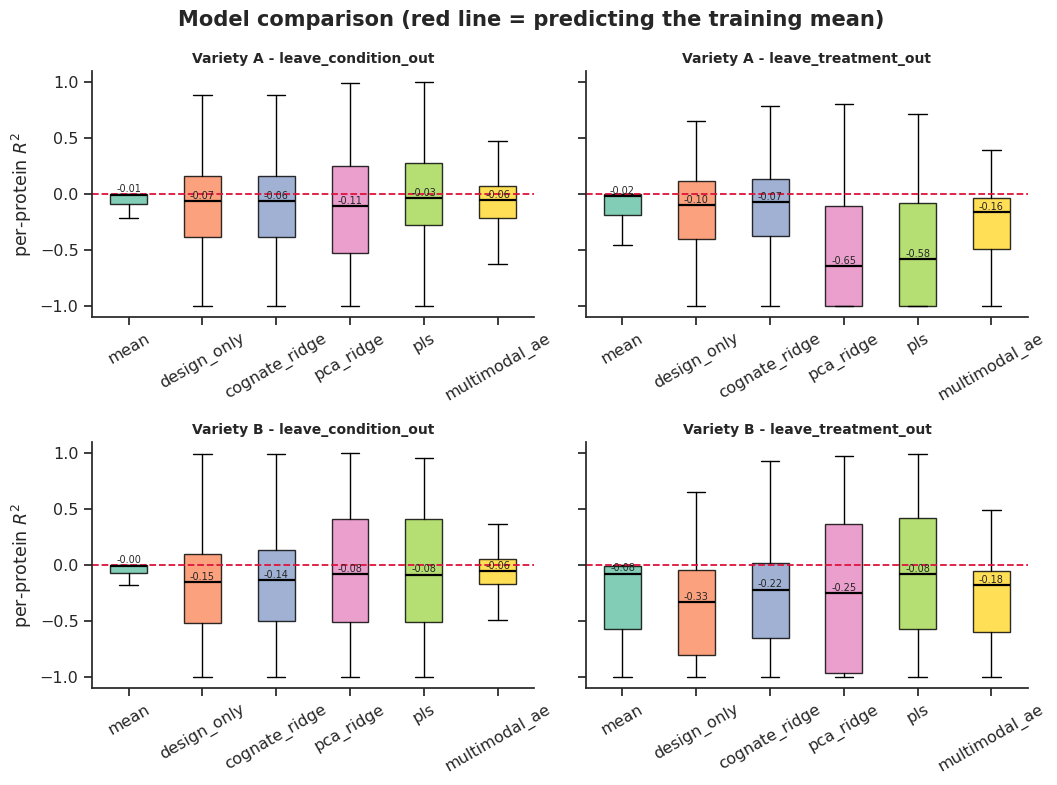

A        leave_condition_out  ratio=0.322
A        leave_treatment_out  ratio=0.333
B        leave_condition_out  ratio=0.292
B        leave_treatment_out  ratio=0.277


In [8]:
# =============================================================================
# FIGURE: model comparison boxplots -- one row per variety, one column per split scheme
# =============================================================================
# Purpose: visualise the per-protein R^2 distribution for all 6 models side by
# side, so you can directly see which model wins, by how much, and whether
# that holds up across different split schemes (honest vs diagnostic).
#
# Grid layout: rows = varieties (A, B, ...), columns = split schemes
# (e.g. leave_condition_out, leave_treatment_out) as set in SPLIT_SCHEMES_WANTED.

# --- model comparison, one row per variety -------------------------------
n_s = len(SPLIT_SCHEMES_WANTED)   # number of columns = number of split schemes

# squeeze=False keeps axes as a 2D array even if there's only 1 row or column,
# so the indexing axes[r][c] below always works regardless of how many
# varieties/schemes you configured
# sharey=True puts every subplot on the same R^2 scale, so box heights are
# directly comparable across varieties and schemes
fig, axes = plt.subplots(len(LABELS), n_s, figsize=(5.4 * n_s, 4.0 * len(LABELS)),
                         squeeze=False, sharey=True)

for r, lab in enumerate(LABELS):          # r = row index, lab = variety label
    for c, scheme in enumerate(SPLIT_SCHEMES_WANTED):   # c = column index
        ax = axes[r][c]

        # the per-protein R^2 table for this variety + split scheme,
        # computed back in the CV cell (columns = model names, rows = proteins)
        t = R2[lab][scheme]

        # only plot models that actually have results in this table, in the
        # canonical display order (mean, design_only, cognate_ridge, ...)
        cols = [m for m in MODEL_ORDER if m in t]

        # boxplot of per-protein R^2 for each model:
        #   - clip(-1, 1) keeps extreme negative outliers from squashing the
        #     plot scale (a model that's WAY worse than the training mean
        #     still shows as clearly negative, just not off the chart)
        #   - showfliers=False hides individual outlier points, since with
        #     hundreds/thousands of proteins the box itself is more readable
        #     than a cloud of dots
        bp = ax.boxplot([t[m].dropna().clip(-1, 1).values for m in cols],
                        tick_labels=cols, patch_artist=True, showfliers=False,
                        medianprops=dict(color="black", lw=1.6))

        # colour each box according to the shared PALETTE (defined in config),
        # so the same model always gets the same colour across every plot
        # in the notebook -- makes cross-referencing figures easier
        for patch, m in zip(bp["boxes"], cols):
            patch.set_facecolor(PALETTE[m]); patch.set_alpha(0.82)

        # reference line at R^2 = 0: this is the "predicting the training
        # mean" baseline. Any model below this line is doing WORSE than a
        # trivial constant prediction -- a model boxplot sitting mostly
        # below the red line is a red flag, not just "low performance"
        ax.axhline(0, color="crimson", lw=1.3, ls="--")

        ax.set_title(f"Variety {lab} - {scheme}", fontweight="bold", fontsize=10)
        ax.tick_params(axis="x", rotation=30)   # angle model names so they fit
        ax.spines[["top", "right"]].set_visible(False)   # cleaner plot style

        # print the exact median R^2 value above each box -- lets you read
        # off precise numbers without hovering/zooming, useful when boxes
        # look visually similar but you need the actual figure for a paper
        for i, m in enumerate(cols):
            ax.text(i + 1, t[m].dropna().clip(-1, 1).median() + 0.02,
                    f"{t[m].median():.2f}", ha="center", fontsize=7)

    # only label the y-axis once per row (leftmost column), since sharey=True
    # means every column in that row already has the same scale
    axes[r][0].set_ylabel("per-protein $R^2$")

fig.suptitle("Model comparison (red line = predicting the training mean)",
             fontweight="bold")
plt.tight_layout()

# save for later use (paper figures, records) and display inline in the notebook
plt.savefig(OUT_DIR / "figures" / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


# =============================================================================
# Check: is the autoencoder's prediction variance collapsing?
# =============================================================================
# A model that's "failing quietly" often does so by predicting something
# close to a constant for every protein/sample, rather than genuinely varying
# its output. That shows up as a boxplot with a very narrow spread near R^2=0
# (exactly what we saw in the figure) -- but R^2 alone doesn't tell you WHY.
# Comparing the standard deviation of predictions vs. the standard deviation
# of the true observed values makes the collapse directly visible:
# a healthy model's predictions should vary almost as much as the real data.

for lab in LABELS:
    for scheme in SPLIT_SCHEMES_WANTED:
        oof = OOF[lab][scheme]
        mask = oof["mask"]
        pred = oof["pred"]["multimodal_ae"][mask]
        obs  = oof["true"][mask]
        ratio = np.std(pred) / np.std(obs)
        print(f"{lab:8s} {scheme:20s} ratio={ratio:.3f}")


In [9]:
# --- paired tests vs pca_ridge -------------------------------------------
for lab in LABELS:
    comp = compare_models(R2[lab][MAIN], reference="pca_ridge")
    comp.to_csv(OUT_DIR / lab / "model_comparison.csv", index=False)
    print(f"=== variety {lab} ({MAIN}) ===")
    display(comp[["model", "median_r2", "median_ref", "median_delta",
                  "win_frac", "wilcoxon_p"]].round(4))

print("median_delta > 0 -> beats pca_ridge on more than half the proteins")
print("At n = 24, expect multimodal_ae to lose. Report it; do not tune until it wins.")

=== variety A (leave_condition_out) ===


,model,median_r2,median_ref,median_delta,win_frac,wilcoxon_p
0,mean,-0.0052,-0.1112,0.0718,0.5600,0.0000
3,pls,-0.0331,-0.1112,0.0718,0.6462,0.0000
4,multimodal_ae,-0.0561,-0.1112,0.0200,0.5162,0.0126
1,design_only,-0.0667,-0.1112,0.0043,0.5025,0.7154
2,cognate_ridge,-0.0602,-0.1112,0.0043,0.5038,0.4440


=== variety B (leave_condition_out) ===


,model,median_r2,median_ref,median_delta,win_frac,wilcoxon_p
0,mean,-0.0038,-0.0767,0.0493,0.5300,0.6307
4,multimodal_ae,-0.0554,-0.0767,-0.0008,0.4975,0.5581
3,pls,-0.0842,-0.0767,-0.0096,0.4375,0.0000
2,cognate_ridge,-0.1361,-0.0767,-0.1283,0.3838,0.0000
1,design_only,-0.1538,-0.0767,-0.1286,0.3900,0.0000


median_delta > 0 -> beats pca_ridge on more than half the proteins
At n = 24, expect multimodal_ae to lose. Report it; do not tune until it wins.


## 5 - Permutation null

Shuffles the protein matrix and reruns the whole CV. Anything surviving this is
a fitting artefact. At n = 24 this control matters more than at n = 48, not
less.

In [ ]:
from rnaprot.evaluate import permutation_null

NULL = {}
if N_PERM > 0:
    for lab in LABELS:
        d = DATA[lab]
        print(f"[variety {lab}] {N_PERM} permutations ...")
        NULL[lab] = permutation_null(d, SPLIT_SCHEMES_SINGLE[MAIN](d.meta),
                                     build_models(), n_perm=N_PERM,
                                     pre_kwargs=PRE_KW,
                                     cognate_index_fn=make_cognate_index_fn(d.cognate))
        NULL[lab].to_csv(OUT_DIR / lab / "permutation_null.csv")
        print(NULL[lab].round(3).to_string())
        print()

    fig, axes = plt.subplots(1, len(LABELS), figsize=(6 * len(LABELS), 3.8),
                             squeeze=False, sharey=True)
    for c, lab in enumerate(LABELS):
        ax = axes[0][c]
        real = {m: R2[lab][MAIN][m].median() for m in MODEL_ORDER if m in R2[lab][MAIN]}
        nullm = NULL[lab].mean(axis=1)
        x = np.arange(len(real))
        ax.bar(x - 0.2, list(real.values()), 0.38, label="real",
               color=[PALETTE[m] for m in real], alpha=0.88)
        ax.bar(x + 0.2, [nullm.get(m, 0) for m in real], 0.38, label="permuted",
               color="lightgray")
        ax.set_xticks(x); ax.set_xticklabels(list(real), rotation=30, ha="right")
        ax.axhline(0, color="crimson", lw=1, ls="--")
        ax.set_title(f"Variety {lab}", fontweight="bold")
        ax.legend(fontsize=8); ax.spines[["top", "right"]].set_visible(False)
    axes[0][0].set_ylabel("median $R^2$")
    fig.suptitle("Real vs permuted labels", fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "figures" / "permutation.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("N_PERM = 0, skipped")

[variety A] 2 permutations ...
               perm0  perm1
model                      
cognate_ridge -0.139 -0.067
design_only   -0.134 -0.065
mean           0.000  0.000
multimodal_ae -0.020 -0.056
pca_ridge     -0.337 -0.145
pls           -0.320 -0.197

[variety B] 2 permutations ...


## 6 - RNA to protein discordance

`D = observed protein - protein predicted from RNA`, out-of-fold, then a
per-protein F-test for treatment dependence with BH correction.

- large but **random** D = measurement noise
- D that **tracks treatment** = post-transcriptional regulation

This is the analysis most likely to survive at n = 24, and the one I would build
the paper on.

In [ ]:
from rnaprot.evaluate import discordance_table, classify_kinetics

DISC, DMAT, CLUST, PROF = {}, {}, {}, {}

for lab in LABELS:
    disc, D = discordance_table(OOF[lab][MAIN], DATA[lab].meta, model="multimodal_ae")
    if TRUTH.get(lab) is not None:
        disc = disc.join(TRUTH[lab]["truth_class"])
    disc.sort_values("q_value").to_csv(OUT_DIR / lab / "discordance.csv")
    D.to_csv(OUT_DIR / lab / "discordance_matrix.csv")
    clusters, prof = classify_kinetics(D, DATA[lab].meta, n_clusters=5)
    clusters.to_frame().join(disc).to_csv(OUT_DIR / lab / "kinetic_clusters.csv")
    DISC[lab], DMAT[lab], CLUST[lab], PROF[lab] = disc, D, clusters, prof
    n_sig = int((disc["q_value"] < 0.05).sum())
    print(f"variety {lab}: {n_sig}/{len(disc)} proteins with treatment-dependent "
          f"residuals at FDR 5%")

print()
display(DISC[LABELS[0]].sort_values("q_value").head(8).round(3))

In [ ]:
# --- volcano per variety --------------------------------------------------
fig, axes = plt.subplots(1, len(LABELS), figsize=(6 * len(LABELS), 4.6), squeeze=False)
for c, lab in enumerate(LABELS):
    ax = axes[0][c]
    d = DISC[lab]
    y = -np.log10(d["p_value"].clip(1e-300))
    if "truth_class" in d:
        pal = dict(zip(sorted(d["truth_class"].unique()),
                       sns.color_palette("tab10", d["truth_class"].nunique())))
        for cls, g in d.groupby("truth_class"):
            ax.scatter(g["mean_abs_discordance"],
                       -np.log10(g["p_value"].clip(1e-300)),
                       s=9, alpha=0.55, label=cls, color=pal[cls])
        ax.legend(fontsize=6.5, markerscale=1.6)
    else:
        sig = d["q_value"] < 0.05
        ax.scatter(d.loc[~sig, "mean_abs_discordance"], y[~sig], s=8,
                   alpha=0.4, color="lightsteelblue", label="ns")
        ax.scatter(d.loc[sig, "mean_abs_discordance"], y[sig], s=10,
                   alpha=0.75, color="crimson", label="FDR < 5%")
        ax.legend(fontsize=8)
    ax.axhline(-np.log10(0.05), ls="--", color="grey", lw=1.1)
    ax.set_xlabel("mean |discordance|")
    ax.set_ylabel(r"$-\log_{10}$ p")
    ax.set_title(f"Variety {lab}", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Where RNA stops explaining protein", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "discordance_volcano.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# --- kinetic clusters of residual trajectories ---------------------------
K = CLUST[LABELS[0]].nunique()
fig, axes = plt.subplots(len(LABELS), K, figsize=(2.6 * K, 3.0 * len(LABELS)),
                         squeeze=False, sharey=True)
pal = sns.color_palette("Set2", K)
for r, lab in enumerate(LABELS):
    prof, cl = PROF[lab], CLUST[lab]
    for i in range(K):
        ax = axes[r][i]
        sub = prof.loc[cl[cl == i].index]
        ax.plot(sub.T.to_numpy(), color="grey", alpha=0.07, lw=0.5)
        ax.plot(sub.mean(axis=0).to_numpy(), color=pal[i], lw=2.4)
        ax.set_title(f"{lab} cluster {i} (n={len(sub)})", fontsize=8, fontweight="bold")
        ax.set_xticks(range(prof.shape[1]))
        ax.set_xticklabels(prof.columns, rotation=80, fontsize=5.5)
        ax.spines[["top", "right"]].set_visible(False)
    axes[r][0].set_ylabel("std. discordance")
fig.suptitle("Regulatory kinetic classes", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "kinetic_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

## 7 - Latent factors within each variety

Refit on all 24 samples of that variety, purely for interpretation. Each latent
dimension is annotated with the fraction of its variance explained by treatment,
timepoint, and their interaction. The variety term is constant here and drops
out automatically.

In [ ]:
from rnaprot.evaluate import latent_design_anova

AE, ZLAT, ANOVA = {}, {}, {}

for lab in LABELS:
    d = DATA[lab]
    print(f"[variety {lab}] fitting on all {d.n_samples} samples ...")
    ae = AERegressor(latent=LATENT, hidden=HIDDEN, dropout=DROPOUT, epochs=EPOCHS,
                     patience=PATIENCE, lr=LR, weight_decay=WEIGHT_DECAY,
                     weights=(W_RECON, W_RECON, W_CROSS, W_ALIGN),
                     groups=d.meta[["treatment", "timepoint"]].astype(str)
                            .agg("|".join, axis=1).to_numpy(),
                     verbose=True).fit(RMAT[lab], PMAT[lab], COV[lab])
    Z = ae.encode(RMAT[lab], COV[lab], "rna")
    pd.DataFrame(Z, index=d.meta.index,
                 columns=[f"z{i+1}" for i in range(Z.shape[1])]) \
      .join(d.meta).to_csv(OUT_DIR / lab / "latent_factors.csv")
    an = latent_design_anova(Z, d.meta.assign(variety="const")) \
         .drop(columns=["variety"], errors="ignore")
    an.to_csv(OUT_DIR / lab / "latent_design_anova.csv")
    AE[lab], ZLAT[lab], ANOVA[lab] = ae, Z, an
    print(f"variety {lab} latent annotation:")
    display(an.round(3))

In [ ]:
# --- latent x design heatmaps --------------------------------------------
fig, axes = plt.subplots(1, len(LABELS), figsize=(6 * len(LABELS), 3.8), squeeze=False)
for c, lab in enumerate(LABELS):
    an = ANOVA[lab]
    cols = [x for x in an.columns if x != "total_R2"]
    ax = axes[0][c]
    im = ax.imshow(an[cols].to_numpy(), aspect="auto", cmap="YlOrRd", vmin=0,
                   vmax=max(0.05, float(an[cols].to_numpy().max())))
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=25, ha="right")
    ax.set_yticks(range(len(an))); ax.set_yticklabels(an.index)
    ax.set_title(f"Variety {lab}", fontweight="bold")
    for i in range(len(an)):
        for j, cc in enumerate(cols):
            v = an[cols].iloc[i, j]
            if v > 0.05:
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                        color="white" if v > 0.35 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Variance of each latent factor explained by design", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "latent_design.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# --- latent scatter + training curves ------------------------------------
fig, axes = plt.subplots(len(LABELS), 3, figsize=(13, 3.8 * len(LABELS)), squeeze=False)
for r, lab in enumerate(LABELS):
    Z, m = ZLAT[lab], DATA[lab].meta
    for c, col in enumerate(["treatment", "timepoint"]):
        ax = axes[r][c]
        grp = m[col].astype(str).to_numpy()
        pal = dict(zip(sorted(set(grp)), sns.color_palette("Set2", len(set(grp)))))
        for gname in sorted(set(grp)):
            s = grp == gname
            ax.scatter(Z[s, 0], Z[s, 1], label=gname, color=pal[gname],
                       s=55, alpha=0.85, edgecolors="white", lw=0.5)
        ax.set_xlabel("z1"); ax.set_ylabel("z2")
        ax.set_title(f"Variety {lab} by {col}", fontweight="bold", fontsize=10)
        ax.legend(fontsize=7); ax.spines[["top", "right"]].set_visible(False)
    ax = axes[r][2]
    ax.plot(AE[lab].history_, color="steelblue", lw=1.8)
    ax.axvline(AE[lab].epochs_run_ - 1, color="crimson", ls="--", lw=1.2,
               label=f"stop @ {AE[lab].epochs_run_}")
    ax.set_xlabel("epoch"); ax.set_ylabel("val cross-modal MSE")
    ax.set_title(f"Variety {lab} training", fontweight="bold", fontsize=10)
    ax.legend(fontsize=8); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "latent_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 8 - Regulatory lag atlas

Per protein, compare `RNA_t -> protein_t` against `RNA_t -> protein_{t+1}`.

Caveat carried over from the n = 48 validation: proteins with a monotone
temporal trend prefer lag-1 trivially. Cross-filter lag hits against the
discordance table before interpreting them.

In [ ]:
from rnaprot.data import lag_pairs
from rnaprot.evaluate import per_protein_r2

LAG = {}
for lab in LABELS:
    d, pre, R, P, cov = DATA[lab], PRE[lab], RMAT[lab], PMAT[lab], COV[lab]
    pairs_idx = make_cognate_index_fn(d.cognate)(pre)
    res = {}
    for lag in (0, 1):
        pr = (np.stack([np.arange(d.n_samples)] * 2, axis=1) if lag == 0
              else lag_pairs(d.meta, lag))
        Rl, Pl, cl = R[pr[:, 0]], P[pr[:, 1]], cov[pr[:, 0]]
        rng = np.random.default_rng(SEED)
        acc = []
        for f in np.array_split(rng.permutation(len(pr)), 4):
            tr = np.setdiff1d(np.arange(len(pr)), f)
            mdl = B.CognateBaseline(pairs_idx).fit(Rl[tr], Pl[tr], cl[tr])
            acc.append(per_protein_r2(Pl[f], mdl.predict(Rl[f], cl[f]),
                                      Pl[tr].mean(axis=0)))
        res[f"r2_lag{lag}"] = np.nanmean(acc, axis=0)
    t = pd.DataFrame(res, index=list(pre.prot_features_))
    t["lag_preference"] = t["r2_lag1"] - t["r2_lag0"]
    t["lag_class"] = np.where(t["lag_preference"] > 0.05, "RNA-first",
                      np.where(t["lag_preference"] < -0.05, "synchronous", "ambiguous"))
    if TRUTH.get(lab) is not None:
        t = t.join(TRUTH[lab]["truth_class"])
    t.sort_values("lag_preference", ascending=False).to_csv(OUT_DIR / lab / "lag_atlas.csv")
    LAG[lab] = t
    print(f"variety {lab}: {t['lag_class'].value_counts().to_dict()}")

In [ ]:
fig, axes = plt.subplots(1, len(LABELS), figsize=(6 * len(LABELS), 4.4), squeeze=False)
cls_col = {"RNA-first": "steelblue", "synchronous": "seagreen", "ambiguous": "lightgray"}
for c, lab in enumerate(LABELS):
    ax = axes[0][c]; t = LAG[lab]
    for cls, g in t.groupby("lag_class"):
        ax.scatter(g["r2_lag0"].clip(-1, 1), g["r2_lag1"].clip(-1, 1), s=9,
                   alpha=0.5, label=cls, color=cls_col.get(cls, "grey"))
    lim = (-0.6, 1.0)
    ax.plot(lim, lim, "k--", lw=1, label="no preference")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(r"$R^2$ (RNA$_t$ -> protein$_t$)")
    ax.set_ylabel(r"$R^2$ (RNA$_t$ -> protein$_{t+1}$)")
    ax.set_title(f"Variety {lab}", fontweight="bold")
    ax.legend(fontsize=7, markerscale=1.6); ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Regulatory lag", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "lag.png", dpi=150, bbox_inches="tight")
plt.show()

for lab in LABELS:
    if "truth_class" in LAG[lab]:
        pct = (LAG[lab].assign(w=LAG[lab]["lag_class"] == "RNA-first")
                       .groupby("truth_class")["w"].mean() * 100).round(1)
        print(f"variety {lab}, % RNA-first by planted class:")
        print(pct.to_string()); print()

## 9 - Cross-variety comparison

This replaces the lost `leave_variety_out` test.

Two comparisons, one of which needs no ortholog map at all:

1. **Latent factor annotation** (no orthologs) - do both varieties organise
   their variation along the same design axes?
2. **Discordance overlap** (needs orthologs) - are the same orthologous genes
   post-transcriptionally regulated in both?

Fisher exact tests whether the significant sets overlap more than chance.
Spearman on the F statistics is the graded version, robust to where you set the
FDR threshold.

In [ ]:
from rnaprot.multivariety import (load_ortholog_map, compare_discordance,
                                   compare_latent_factors, compare_lag)

if len(LABELS) < 2:
    print("only one variety loaded, nothing to compare")
else:
    a, b = LABELS[0], LABELS[1]

    lat = compare_latent_factors(ANOVA[a], ANOVA[b])
    lat.to_csv(OUT_DIR / "cross_variety_latent.csv", index=False)
    print("Latent factor annotation, both varieties (no orthologs needed):")
    display(lat.round(3))

    SUMMARY = {}
    if ORTHOLOG_CSV is None:
        print("ORTHOLOG_CSV is None - skipping gene-level comparison.")
        CROSS = None
    else:
        ortho = load_ortholog_map(ORTHOLOG_CSV)
        print(f"ortholog map: {len(ortho):,} pairs")
        CROSS = compare_discordance(DISC[a], DISC[b], ortho)
        CROSS["merged"].to_csv(OUT_DIR / "cross_variety_discordance.csv", index=False)
        SUMMARY["discordance"] = {k: v for k, v in CROSS.items()
                                  if k not in ("merged", "contingency")}
        SUMMARY["discordance"]["contingency"] = CROSS["contingency"].tolist()
        print(f"  orthologs matched   : {CROSS['n_orthologs']:,}")
        print(f"  conserved (both sig): {CROSS['n_conserved']:,}")
        print(f"  {a}-specific        : {CROSS['n_a_only']:,}")
        print(f"  {b}-specific        : {CROSS['n_b_only']:,}")
        print(f"  Fisher odds={CROSS['fisher_odds']:.2f}  p={CROSS['fisher_p']:.3g}")
        print(f"  Spearman rho={CROSS['spearman_rho']:.3f}  p={CROSS['spearman_p']:.3g}")

        lagres = compare_lag(LAG[a], LAG[b], ortho)
        if lagres["n"]:
            lagres["merged"].to_csv(OUT_DIR / "cross_variety_lag.csv", index=False)
            SUMMARY["lag"] = {k: v for k, v in lagres.items() if k != "merged"}
            print(f"  lag class agreement : {lagres['class_agreement']:.1%}")

        json.dump(SUMMARY, open(OUT_DIR / "cross_variety_summary.json", "w"), indent=2)

In [ ]:
if len(LABELS) >= 2 and CROSS is not None:
    m = CROSS["merged"]
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

    ax = axes[0]
    ax.scatter(np.log10(np.clip(m["F_stat_a"], 1e-3, None)),
               np.log10(np.clip(m["F_stat_b"], 1e-3, None)),
               s=10, alpha=0.45, color="steelblue")
    ax.set_xlabel(f"log10 F statistic, variety {LABELS[0]}")
    ax.set_ylabel(f"log10 F statistic, variety {LABELS[1]}")
    ax.set_title(f"Discordance effect sizes\nSpearman rho = {CROSS['spearman_rho']:.2f}, "
                 f"p = {CROSS['spearman_p']:.2g}", fontweight="bold", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

    ax = axes[1]
    counts = m["class"].value_counts()
    colors = {"conserved": "seagreen", f"variety_A_specific": "steelblue",
              f"variety_B_specific": "orange", "neither": "lightgray"}
    ax.bar(counts.index, counts.values,
           color=[colors.get(k, "grey") for k in counts.index])
    for i, v in enumerate(counts.values):
        ax.text(i, v + max(counts.values) * 0.01, str(v), ha="center", fontsize=8)
    ax.set_ylabel("orthologs"); ax.tick_params(axis="x", rotation=18)
    ax.set_title(f"Conserved vs variety-specific\nFisher p = {CROSS['fisher_p']:.3g}",
                 fontweight="bold", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle("Cross-variety reproducibility of post-transcriptional regulation",
                 fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "figures" / "cross_variety.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("no ortholog comparison to plot")

## 10 - Output summary

In [ ]:
print(f"outputs -> {OUT_DIR.resolve()}")
print()
for f in sorted(OUT_DIR.rglob("*")):
    if f.is_file():
        print(" ", f.relative_to(OUT_DIR))

---
## Reading your results

| what you see | what it means | what to do |
|---|---|---|
| `multimodal_ae` loses to `pca_ridge` in both varieties | RNA to protein mapping is essentially linear at this sample size | report the linear model; this is a finding, not a failure |
| `design_only` matches everything | models learned the experimental design, not RNA biology | check preprocessing; RNA may carry little protein-relevant signal |
| `leave_treatment_out` collapses but `leave_condition_out` is fine | treatment altered the RNA to protein mapping | this is a headline biological result, not a bug |
| Fisher p < 0.05, odds > 1 in section 9 | the same orthologs are discordant in both varieties | strong reproducibility claim, lead with it |
| Fisher not significant | variety-specific regulation, **or** underpowered at n = 24 | report the odds ratio alongside the p-value; do not over-read a null |
| permuted R2 close to real R2 | the signal is fitting artefact | stop and investigate before interpreting anything |

**On the demo:** the two synthetic varieties come from different random seeds,
so they share no biology by construction. The cross-variety comparison should
return a null. If it does, your pipeline is calibrated correctly.

**Normalisation reminder:** each variety is normalised independently. Do not
concatenate the count matrices before loading, because the two assemblies have
different gene counts and the CPM denominators are not comparable.